# Model Training and Cross-Architecture Benchmarking.

Train and benchmark four convolutional architectures (MobileNetV2, EfficientNet-B0,
ResNet-50 and the custom Victorio CNN) across two initialisation regimes on the
patient-grouped clean corpus produced by `scripts/build_clean_corpus.py`.

#### Rationale:
- Establish a single, auditable configuration point so that the initialisation
  regime and the normalisation statistics can never disagree.
- Read exclusively from `experiments/pools_clean/`, the deduplicated and
  patient-grouped corpus, so that reported metrics reflect genuine generalisation.
- Verify split disjointness before any weights are updated, rather than inferring
  leakage from implausible accuracies afterwards.
- Produce checkpoints and per-epoch metrics under a consistent naming scheme for
  downstream evaluation, explainability and deployment notebooks.

## 1. Setup and Artefact Load.

Prepare the training environment and load the preprocessing artefacts persisted by
`01_data_eda.ipynb`. The image size is deliberately not read from the configuration
file: it is owned by the experiment configuration cell so that the selected training
stage genuinely determines the input resolution.

#### Rationale:
- Establish a reproducible experimental context (fixed random seed and deterministic
  cuDNN - NVIDIA CUDA Deep Neural Network library).
- Resolve canonical project paths and create the output directories for checkpoints
  and metrics, keeping training runs auditable.
- Load the class mapping and normalisation constants that define the three-class
  problem (Normal, Pneumonia, TB).
- Print a concise summary confirming GPU availability, precision mode and
  reproducibility settings.

In [1]:
from pathlib import Path
import os, json, random, numpy as np, pandas as pd, torch

# Reproducibility.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

# Canonical project paths.
PROJECT_ROOT    = Path("..").resolve()
CHEXPERT_PATH   = PROJECT_ROOT / "data" / "chexpert"
TBX11K_PATH     = PROJECT_ROOT / "data" / "tbx11k"
POOLS_DIR       = PROJECT_ROOT / "experiments" / "pools"
SPLITS_DIR      = PROJECT_ROOT / "experiments" / "pools_clean"
CHECKPOINTS_DIR = PROJECT_ROOT / "experiments" / "checkpoints"
RESULTS_DIR     = PROJECT_ROOT / "experiments" / "results"

for folder in [CHECKPOINTS_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

cfg_path = POOLS_DIR / "preprocessing_config.json"
if not cfg_path.exists():
    raise FileNotFoundError(
        "Missing experiments/pools/preprocessing_config.json. Run 01_data_eda.ipynb first."
    )
cfg = json.loads(cfg_path.read_text())

CLASS_TO_INDEX = {k: int(v) for k, v in cfg["class_to_index"].items()}
INDEX_TO_CLASS = {v: k for k, v in CLASS_TO_INDEX.items()}
TRANSFORM_MODE = cfg.get("transform_mode", "center-crop")

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(device.type == "cuda")

print("03_model_training - Environment")
print(f"- Device: {device.type.upper()} | PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}")
if device.type == "cuda":
    print(f"- GPU: {torch.cuda.get_device_name(0)} | cuDNN: {torch.backends.cudnn.version()}")
print(f"- Class map: {CLASS_TO_INDEX}")
print(f"- Transform mode: {TRANSFORM_MODE}")
print(f"- Seed: {SEED} | Deterministic cuDNN: {torch.backends.cudnn.deterministic}")
print(f"- Precision: {'Mixed (AMP)' if USE_AMP else 'FP32'}")

03_model_training - Environment
- Device: CUDA | PyTorch: 2.10.0.dev20250930+cu128 | CUDA: 12.8
- GPU: NVIDIA GeForce RTX 5090 Laptop GPU | cuDNN: 91002
- Class map: {'Pneumonia': 0, 'TB': 1, 'Normal': 2}
- Transform mode: letterbox
- Seed: 42 | Deterministic cuDNN: True
- Precision: Mixed (AMP)


## 2. Module Import Path Setup.

Ensure that the project's internal modules stored under `/src` (such as
`/src/dataset.py` and `/src/transforms.py`) are discoverable when the notebook is
executed from within the `/notebooks` directory. By explicitly adding the parent
directory to `sys.path`, Python recognises the custom package structure regardless
of runtime environment (local workstation, remote server, or container).

#### Rationale:
- Avoids import errors when running notebooks from nested directories by dynamically
  adding the project root to the Python path.
- Guarantees modular reproducibility and environmental portability across local and
  cloud-based executions.
- Placed ahead of every cell that imports from `src`, so that import resolution is
  established before it is required.
- Aligns the notebook workflow with the structure used for later containerised and
  Kubernetes deployments.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added to sys.path:", PROJECT_ROOT)

Project root added to sys.path: /lab/px/AnichLabs/cxr-cnn-k8s-benchmark


## 3. Experiment Configuration.

Define the complete specification for a single training run from one cell. Three
values are set by hand (architecture, training regime and training stage) and
every remaining setting is derived from them. This is the only cell that should
be edited between runs.

A regime specifies two things that are logically separate: how the weights are
initialised, and which normalisation statistics are applied. For the three
pretrained backbones the two move together. For the custom architecture, which
has no ImageNet weights, only the normalisation can vary, so its two regimes
differ in normalisation alone. Both quantities are therefore derived and
reported independently rather than inferred from the regime name.

#### Rationale:
- Derive the initialisation and the normalisation from a single `REGIME` value,
  so that an ImageNet-pretrained backbone cannot silently be paired with
  dataset-specific normalisation, which was the defect in the submitted work.
- Record initialisation and normalisation as separate fields, so that the
  asymmetry affecting the custom architecture is explicit in the output rather
  than implied by a label.
- Centralise stage-dependent hyperparameters (resolution, epochs, batch size and
  learning rate) so that quick, pilot and full runs differ only in scale.
- Emit a single canonical run identifier used for the checkpoint, the metrics
  file and the run manifest, removing duplicated naming logic from the training
  loop.

In [4]:
# SINGLE SOURCE OF TRUTH FOR THIS RUN.

MODEL_NAME = "victorio"   # victorio | mobilenet_v2 | efficientnet_b0 | resnet50
REGIME     = "cxr"        # imagenet | cxr
MODE       = "full"       # quick | pilot | full

# --- Derived. Do not edit below this line. ---

ARCHITECTURES = {"victorio", "mobilenet_v2", "efficientnet_b0", "resnet50"}

# Architectures for which torchvision provides ImageNet weights. Victorio is a
# custom design and has none, so its initialisation is always random.
HAS_IMAGENET_WEIGHTS = {"mobilenet_v2", "efficientnet_b0", "resnet50"}

if REGIME not in {"imagenet", "cxr"}:
    raise ValueError(f"Unknown REGIME: {REGIME}")
if MODEL_NAME not in ARCHITECTURES:
    raise ValueError(f"Unknown MODEL_NAME: {MODEL_NAME}")

# A regime fixes two logically separate things. Derive them independently so the
# distinction survives into the output, rather than being implied by a label.
#
#   NORMALISATION follows the regime for every architecture.
#   INITIALISATION follows the regime only where pretrained weights exist.
#
# Consequence for Victorio: its two regimes differ in normalisation alone, both
# starting from random initialisation. Section 3.3 of the paper must say so.
NORMALISATION  = "imagenet" if REGIME == "imagenet" else "cxr"
INITIALISATION = ("imagenet"
                  if REGIME == "imagenet" and MODEL_NAME in HAS_IMAGENET_WEIGHTS
                  else "random")

PRETRAINED         = (INITIALISATION == "imagenet")
USE_IMAGENET_STATS = (NORMALISATION == "imagenet")

if MODE == "quick":        # Debugging and stability checks (minutes).
    IMG_SIZE, NUM_EPOCHS, BATCH_SIZE, BASE_LR = 128, 3, 32, 3e-4
elif MODE == "pilot":
    IMG_SIZE, NUM_EPOCHS, BATCH_SIZE, BASE_LR = 224, 15, 64, 2e-4
elif MODE == "full":       # Overnight runs.
    IMG_SIZE, NUM_EPOCHS, BATCH_SIZE, BASE_LR = 256, 60, 128, 1e-4
else:
    raise ValueError(f"Unknown MODE: {MODE}")

WEIGHT_DECAY = 1e-4
FINETUNE     = True      # Unfreeze all backbone layers.
PATIENCE     = 8         # Early-stopping patience, in epochs.

RUN_TAG = f"{MODEL_NAME}_{REGIME}" + ("_best" if MODE == "full" else f"_{MODE}")

print(f"Run: {RUN_TAG}")
print(f"  architecture   : {MODEL_NAME}")
print(f"  regime         : {REGIME}")
print(f"  initialisation : {INITIALISATION}"
      + ("" if MODEL_NAME in HAS_IMAGENET_WEIGHTS
         else "  (no ImageNet weights exist for this architecture)"))
print(f"  normalisation  : {NORMALISATION}")
print(f"  stage          : {MODE.upper()} | {IMG_SIZE}px | {NUM_EPOCHS} epochs "
      f"| batch {BATCH_SIZE} | lr {BASE_LR:.1e}")

if REGIME == "imagenet" and INITIALISATION == "random":
    print()
    print("  NOTE: this regime differs from the CXR regime in normalisation only. "
          "Report it as such.")

Run: victorio_cxr_best
  architecture   : victorio
  regime         : cxr
  initialisation : random  (no ImageNet weights exist for this architecture)
  normalisation  : cxr
  stage          : FULL | 256px | 60 epochs | batch 128 | lr 1.0e-04


## 4. Normalisation Statistics.

Select the normalisation source for preprocessing. ImageNet statistics reproduce the
distribution the pretrained filters were trained on, whereas the dataset-specific
statistics computed in `01_data_eda.ipynb` match the true brightness and contrast of
the chest radiographs.

#### Rationale:
- Applies ImageNet mean and standard deviation when the backbone carries pretrained
  weights, so that transferred filters receive the expected input distribution.
- Applies CXR statistics when training from random initialisation, so that
  normalisation matches the chest X-ray domain.
- Derives the choice from `REGIME` rather than an independent toggle, eliminating the
  possibility of a mismatched pairing.
- Maintains consistent preprocessing across architectures, enabling fair comparison
  between pretrained backbones and the custom CNN.

In [5]:
if USE_IMAGENET_STATS:
    MEAN, STD = cfg["imagenet_mean"], cfg["imagenet_std"]
    norm_source = "ImageNet"
else:
    MEAN, STD = cfg["cxr_mean"], cfg["cxr_std"]
    norm_source = "CXR (dataset-specific)"

print(f"Using {norm_source} normalisation:")
print(f"  mean = {MEAN}")
print(f"  std  = {STD}")

Using CXR (dataset-specific) normalisation:
  mean = [0.5336471796035767, 0.5336471796035767, 0.5336471796035767]
  std  = [0.26645559072494507, 0.26645559072494507, 0.26645559072494507]


## 5. Shared Preprocessing Transforms.

Construct the shared preprocessing pipelines for training and evaluation using the
resolution selected in the configuration cell and the normalisation statistics
resolved above. These transforms include deterministic resizing, letterbox padding
and normalisation, ensuring that images from all four sources are processed
identically.

#### Rationale:
- Enforces standardised input statistics across sources for fair comparison between
  custom and pretrained models.
- Applies augmentation only to the training pipeline, leaving evaluation
  deterministic.
- Runs after the configuration cell, so the transforms reflect the resolution of the
  selected training stage rather than a stale default.
- Promotes reproducibility by applying identical preprocessing logic in every
  subsequent experiment.

In [6]:
from src.transforms import build_shared_transforms

train_transforms_shared, eval_transforms_shared = build_shared_transforms(
    img_size=IMG_SIZE,
    mean=MEAN,
    std=STD,
)

print(f"Transforms built: {IMG_SIZE}x{IMG_SIZE} ({norm_source}-normalised)")

Transforms built: 256x256 (CXR (dataset-specific)-normalised)


## 6. Stratified Train and Validation DataLoaders.

Load the train and validation DataLoaders from the patient-grouped splits created by
`scripts/build_clean_corpus.py`. All three classes maintain proportional
representation without re-splitting the pool. Batch size follows the selected
training stage, and the split sizes are asserted before any dataset object is
constructed.

#### Rationale:
- Preserves class balance across splits, preventing training bias and enabling robust
  evaluation.
- Reads exclusively from `experiments/pools_clean/`, never from the superseded
  contaminated pool.
- Fails loudly if the split sizes depart from the expected 2,255 train and 481
  validation rows, so that an incorrect corpus is detected before training rather
  than inferred from implausible accuracy afterwards.
- Uses parallel workers and pinned memory to maximise GPU utilisation and minimise
  I/O latency.

In [7]:
import pandas as pd
from torch.utils.data import DataLoader
from src.dataset import CXRThreeClassDataset

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
val_df   = pd.read_csv(SPLITS_DIR / "val_split.csv")

print(f"Splits from: {SPLITS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Train split size: {len(train_df):,}")
print(f"Validation split size: {len(val_df):,}")
print("Train class balance:")
print(train_df["Class"].value_counts().to_string())

# The clean corpus is 2,255 train / 481 val / 480 test.
EXPECTED_TRAIN, EXPECTED_VAL = 2255, 481
if (len(train_df), len(val_df)) != (EXPECTED_TRAIN, EXPECTED_VAL):
    raise ValueError(
        f"Unexpected split sizes: {len(train_df)} train / {len(val_df)} val. "
        f"Expected {EXPECTED_TRAIN} / {EXPECTED_VAL} for the clean corpus. "
        "Check that experiments/pools_clean/ holds the rebuilt splits."
    )

train_dataset = CXRThreeClassDataset(
    items=train_df, class_to_index=CLASS_TO_INDEX,
    transforms=train_transforms_shared,
    chexpert_root=CHEXPERT_PATH, tbx_root=TBX11K_PATH,
)
val_dataset = CXRThreeClassDataset(
    items=val_df, class_to_index=CLASS_TO_INDEX,
    transforms=eval_transforms_shared,
    chexpert_root=CHEXPERT_PATH, tbx_root=TBX11K_PATH,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True,
)

print(f"Loaders ready: batch size {BATCH_SIZE}")

Splits from: experiments/pools_clean
Train split size: 2,255
Validation split size: 481
Train class balance:
Class
Pneumonia    753
Normal       751
TB           751
Loaders ready: batch size 128


## 7. Model Initialisation.

Instantiate the neural network architecture selected in the configuration cell and
move it to the active device. The final classification layer of each backbone is
replaced to match the three-class problem.

#### Rationale:
- Maintains a consistent construction path across all model types (custom CNN and
  transfer-learning backbones).
- Takes both the architecture and the weight initialisation from the configuration
  cell, so that the regime recorded in the run identifier is the regime actually
  used.
- Reports the parameter count, supporting the capacity comparison discussed in the
  results.
- Supports fair comparison of model performance under controlled experimental
  conditions.

In [8]:
from torchvision import models
import torch.nn as nn

W = "IMAGENET1K_V1" if PRETRAINED else None

if MODEL_NAME == "mobilenet_v2":
    model = models.mobilenet_v2(weights=W)
    model.classifier[1] = nn.Linear(model.last_channel, len(CLASS_TO_INDEX))
elif MODEL_NAME == "efficientnet_b0":
    model = models.efficientnet_b0(weights=W)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(CLASS_TO_INDEX))
elif MODEL_NAME == "resnet50":
    model = models.resnet50(weights=W)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_TO_INDEX))
elif MODEL_NAME == "victorio":
    # victorio:v1.0, named in memory of Dr Victorio Corradi.
    model = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.AdaptiveAvgPool2d((4, 4)),
        nn.Flatten(),
        nn.Linear(32 * 4 * 4, len(CLASS_TO_INDEX)),
    )

model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"{MODEL_NAME}: {n_params:,} parameters | initialisation: {INITIALISATION}")

victorio: 6,627 parameters | initialisation: random


## 8. Debug Confirmation (CUDA and Device Sanity Check).

Verify that the GPU environment is correctly initialised before training. This
diagnostic step confirms that PyTorch can access the NVIDIA RTX 5090 device,
initialise CUDA contexts, and allocate tensors for computation.

#### Rationale:
- Ensures CUDA and cuDNN are properly loaded and functional in the active
  environment.
- Confirms hardware acceleration is available for model training and evaluation.
- Prevents silent fallbacks to CPU execution, maintaining reproducibility and
  performance consistency.
- Asserts the output dimensionality matches the three-class label map, catching an
  incorrectly replaced classification head.

In [9]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))
    print("Total GPU memory (GB):",
          round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    out = model(x)
print("Output shape:", out.shape)
assert out.shape == (4, len(CLASS_TO_INDEX)), "Unexpected output shape."

CUDA available: True
Device name: NVIDIA GeForce RTX 5090 Laptop GPU
Total GPU memory (GB): 25.15
Output shape: torch.Size([4, 3])


## 9. Optimiser, Scheduler and Loss Configuration.

Configure the optimisation strategy for the selected training stage: parameter
freezing behaviour, the AdamW optimiser, a cosine-annealing schedule with linear
warm-up, and the loss function with label smoothing.

#### Rationale:
- Enables reproducible training by using identical optimiser and scheduler settings
  across architectures.
- Supports fine-tuning and selective layer unfreezing for transfer-learning
  backbones.
- Clamps the warm-up length to the run length, preventing short runs from consisting
  entirely of warm-up with no annealing phase.
- Scales dropout with the training stage, applying lighter regularisation to short
  diagnostic runs.

In [10]:
import math
from torch import optim
import torch.nn as nn

if FINETUNE:
    for p in model.parameters():
        p.requires_grad = True
    print("Fine-tuning enabled: all backbone layers trainable.")
else:
    print("Backbone frozen: only classifier layers trainable.")
    if hasattr(model, "features"):
        for p in model.features.parameters():
            p.requires_grad = False
    elif hasattr(model, "layer1"):
        for p in model.layer1.parameters():
            p.requires_grad = False

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=BASE_LR, weight_decay=WEIGHT_DECAY,
)

def build_scheduler(optimizer, num_epochs, warmup_epochs=3):
    warmup_epochs = min(warmup_epochs, max(1, num_epochs - 1))
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / float(max(1, num_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = build_scheduler(optimizer, NUM_EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

for m in model.modules():
    if isinstance(m, nn.Dropout):
        m.p = 0.4 if MODE != "quick" else 0.25
    if isinstance(m, nn.BatchNorm2d):
        m.momentum = 0.1

print(f"Optimiser ready: AdamW, lr={BASE_LR:.1e}, wd={WEIGHT_DECAY:.1e}")

Fine-tuning enabled: all backbone layers trainable.
Optimiser ready: AdamW, lr=1.0e-04, wd=1.0e-04


## 10. Pre-Training Diagnostics and Dry-Run Validation.

Before executing the full training routine, a short diagnostic stage confirms that
the data pipeline, model and optimiser are operational together. Running these checks
prevents wasting hours of computation on silent configuration or runtime errors.

#### Rationale:
- Confirms DataLoaders yield batches of the expected shape, asserting agreement
  between the loaders and the resolution selected for this stage.
- Validates the forward and backward pass, detecting shape or precision mismatches.
- Executes a one-batch dry run to measure memory usage and prevent out-of-memory
  crashes.
- Confirms gradients flow through the optimiser and gradient scaler before committing
  to a long run.

In [11]:
from torch.amp import autocast, GradScaler

images, labels = next(iter(train_loader))
print(f"Sample batch shape: {tuple(images.shape)} | Labels: {labels[:8].tolist()}")

expected = (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE)
assert tuple(images.shape) == expected, \
    f"Batch shape {tuple(images.shape)} != expected {expected}"

scaler = GradScaler("cuda", enabled=USE_AMP)
images, labels = images.to(device), labels.to(device)

with autocast("cuda", enabled=USE_AMP):
    outputs = model(images)
    loss = criterion(outputs, labels)
print(f"Forward pass OK. Loss: {loss.item():.4f}")

optimizer.zero_grad(set_to_none=True)
scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()
print("Backward + optimiser step OK.")
print()
print("Diagnostics passed. Ready for training loop.")

Sample batch shape: (128, 3, 256, 256) | Labels: [1, 2, 2, 2, 0, 0, 1, 1]
Forward pass OK. Loss: 1.0924
Backward + optimiser step OK.

Diagnostics passed. Ready for training loop.


## 11. Split Integrity Check.

Verify that the training and validation splits share no material at any level. The
check uses the content hash, patient group and relative path columns emitted by
`scripts/build_clean_corpus.py`, comparing them directly rather than re-deriving them
from the image files.

#### Rationale:
- Detects duplicates by image content, not by file name or path, so that visually
  identical images are caught regardless of directory structure or naming.
- Checks patient group membership, preventing leakage from multiple studies of the
  same patient appearing on both sides of the split.
- Reads the precomputed columns rather than re-hashing every image, so the check
  completes in under a second and can run before every training execution.
- Raises before training begins if any overlap is present, guaranteeing that
  evaluation metrics reflect true generalisation rather than memorisation.

In [12]:
checks = {
    "content hash":  set(train_df["hash"])     & set(val_df["hash"]),
    "patient group": set(train_df["group"])    & set(val_df["group"]),
    "file path":     set(train_df["rel_path"]) & set(val_df["rel_path"]),
}

print("--- TRAIN / VAL DISJOINTNESS ---")
failed = []
for label, overlap in checks.items():
    status = "PASS" if not overlap else f"FAIL ({len(overlap)} shared)"
    print(f"{label:15s}: {status}")
    if overlap:
        failed.append(label)

if failed:
    raise ValueError(f"Split leakage detected on: {', '.join(failed)}. Do not train.")

print()
print("All disjointness checks passed.")

--- TRAIN / VAL DISJOINTNESS ---
content hash   : PASS
patient group  : PASS
file path      : PASS

All disjointness checks passed.


## 12. Training Loop and Metrics Tracking.

Train and validate the selected model over multiple epochs while monitoring loss and
accuracy. This section implements a reproducible supervised training loop compatible
with both custom and transfer-learning architectures.

#### Rationale:
- Executes iterative optimisation of network weights over mini-batches using
  backpropagation and gradient-based updates.
- Monitors training and validation loss and accuracy at each epoch to detect
  underfitting, overfitting, or training instabilities.
- Applies scheduled learning-rate updates and early stopping to improve convergence
  and prevent unnecessary computation.
- Saves the best-performing checkpoint and per-epoch metrics under the canonical run
  identifier, enabling statistical comparison across architectures, stages and
  initialisation regimes in later notebooks.

In [13]:
from torch.amp import autocast, GradScaler
from tqdm import tqdm
import time, json

best_val_acc = 0.0
scaler = GradScaler("cuda", enabled=USE_AMP)

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

def run_epoch(loader, model, criterion, optimizer=None, train=False):
    """One full pass over a DataLoader. Returns (mean_loss, mean_accuracy)."""
    model.train(train)
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Train" if train else "Val", leave=False):
        images, labels = images.to(device), labels.to(device)

        with autocast(device_type="cuda", enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        bs = labels.size(0)
        total_loss    += loss.item() * bs
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_seen    += bs

    return total_loss / total_seen, total_correct / total_seen


print(f"Starting training: {RUN_TAG} | {NUM_EPOCHS} epochs on {device} ...")
start_time = time.time()
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer, train=True
    )

    with torch.no_grad():
        val_loss, val_acc = run_epoch(val_loader, model, criterion, train=False)

    scheduler.step()

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch: {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        ckpt_path = CHECKPOINTS_DIR / f"{RUN_TAG}.pt"
        torch.save(model.state_dict(), ckpt_path)
        print(f"--- New best model saved --> {ckpt_path.name} (val_acc={val_acc:.4f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{PATIENCE} epochs.")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

results_path = RESULTS_DIR / f"{RUN_TAG}_metrics.json"
with open(results_path, "w") as f:
    json.dump(history, f, indent=2)

# Run manifest. Records what was actually executed, so that the paper can be
# checked against the code rather than against recollection. The submitted work
# claimed a from-scratch regime that the code did not implement; this file makes
# that class of drift detectable.
manifest = {
    "run_tag": RUN_TAG,
    "architecture": MODEL_NAME,
    "parameters": int(n_params),
    "regime": REGIME,
    "initialisation": INITIALISATION,
    "normalisation": NORMALISATION,
    "normalisation_mean": MEAN,
    "normalisation_std": STD,
    "mode": MODE,
    "img_size": IMG_SIZE,
    "epochs_configured": NUM_EPOCHS,
    "epochs_run": len(history["epoch"]),
    "batch_size": BATCH_SIZE,
    "base_lr": BASE_LR,
    "weight_decay": WEIGHT_DECAY,
    "finetune": FINETUNE,
    "patience": PATIENCE,
    "label_smoothing": 0.05,
    "seed": SEED,
    "splits_dir": str(SPLITS_DIR.relative_to(PROJECT_ROOT)),
    "train_size": len(train_df),
    "val_size": len(val_df),
    "best_val_acc": best_val_acc,
    "checkpoint": f"{RUN_TAG}.pt",
    "torch_version": torch.__version__,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
}
manifest_path = RESULTS_DIR / f"{RUN_TAG}_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

elapsed = (time.time() - start_time) / 60
print()
print(f"Training completed in {elapsed:.2f} minutes.")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Metrics saved to:  {results_path.relative_to(PROJECT_ROOT)}")
print(f"Manifest saved to: {manifest_path.relative_to(PROJECT_ROOT)}")

Starting training: victorio_cxr_best | 60 epochs on cuda ...


Epoch: 01/60 | Train Loss: 1.0859, Accuracy: 0.4098 | Val Loss: 1.0790, Accuracy: 0.4428
--- New best model saved --> victorio_cxr_best.pt (val_acc=0.4428)


Epoch: 02/60 | Train Loss: 1.0728, Accuracy: 0.5042 | Val Loss: 1.0630, Accuracy: 0.5655
--- New best model saved --> victorio_cxr_best.pt (val_acc=0.5655)


Epoch: 03/60 | Train Loss: 1.0523, Accuracy: 0.5814 | Val Loss: 1.0368, Accuracy: 0.5884
--- New best model saved --> victorio_cxr_best.pt (val_acc=0.5884)


Epoch: 04/60 | Train Loss: 1.0210, Accuracy: 0.6151 | Val Loss: 1.0007, Accuracy: 0.6154
--- New best model saved --> victorio_cxr_best.pt (val_acc=0.6154)


...

Epoch: 40/60 | Train Loss: 0.5279, Accuracy: 0.8457 | Val Loss: 0.6019, Accuracy: 0.7921
No improvement for 4/8 epochs.


Epoch: 41/60 | Train Loss: 0.5281, Accuracy: 0.8443 | Val Loss: 0.5997, Accuracy: 0.7942
No improvement for 5/8 epochs.


Epoch: 42/60 | Train Loss: 0.5268, Accuracy: 0.8492 | Val Loss: 0.6008, Accuracy: 0.7942
No improvement for 6/8 epochs.


Epoch: 43/60 | Train Loss: 0.5257, Accuracy: 0.8461 | Val Loss: 0.5999, Accuracy: 0.7942
No improvement for 7/8 epochs.


Epoch: 44/60 | Train Loss: 0.5246, Accuracy: 0.8479 | Val Loss: 0.5996, Accuracy: 0.7942
No improvement for 8/8 epochs.
Early stopping triggered at epoch 44.

Training completed in 3.59 minutes.
Best validation accuracy: 0.7963
Metrics saved to:  experiments/results/victorio_cxr_best_metrics.json
Manifest saved to: experiments/results/victorio_cxr_best_manifest.json


## 13. Metric Visualisation and Statistical Summary.

Compare the performance of all trained models by loading every `*_metrics.json` file
stored in `experiments/results/`. Each metrics file contains the recorded training and
validation losses and accuracies per epoch.

#### Rationale:
- Enables direct performance comparison between architectures and initialisation
  regimes (ImageNet versus CXR).
- Evaluates convergence behaviour and potential overfitting trends through paired
  small multiples, one panel per architecture.
- Provides a compact statistical overview of validation accuracy for all
  architectures, exported to `reports/tables/` for reuse in the paper.
- Requires that metrics from superseded runs be archived first, so that the
  comparison never mixes results computed on different corpora.

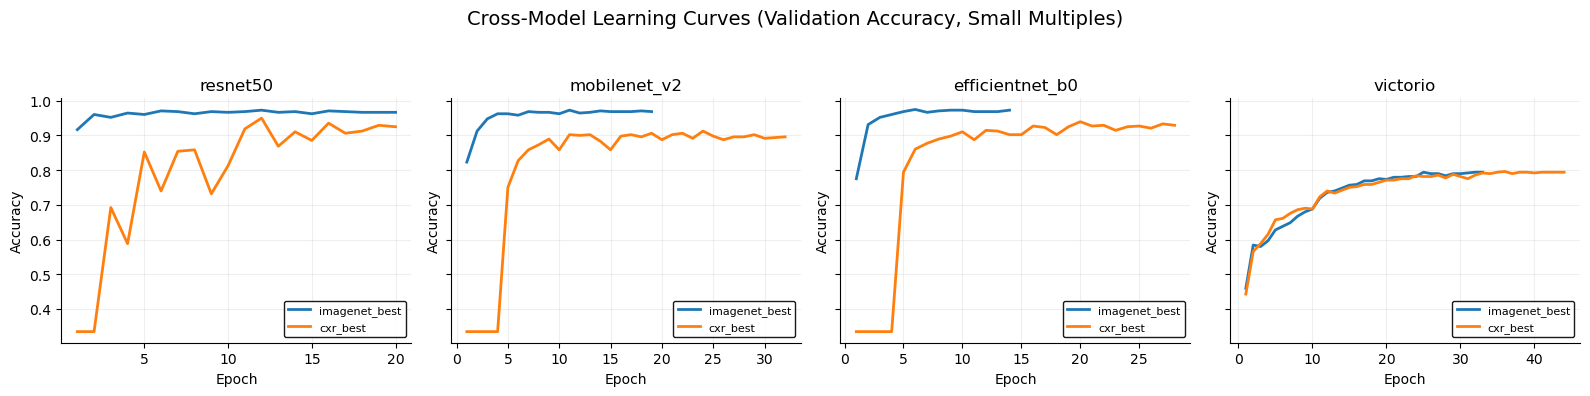

Figure saved to: reports/figures/cross_model_comparison_small_multiples.png

Summary of Validation Accuracy (Ordered by FINAL Accuracy):

Model                          | Best Acc | Epoch |  Final Acc
------------------------------------------------------------
efficientnet_b0_imagenet_best  | 0.9751 |     6 | 0.9730
mobilenet_v2_imagenet_best     | 0.9730 |    11 | 0.9688
resnet50_imagenet_best         | 0.9730 |    12 | 0.9667
efficientnet_b0_cxr_best       | 0.9397 |    20 | 0.9293
resnet50_cxr_best              | 0.9501 |    12 | 0.9252
mobilenet_v2_cxr_best          | 0.9127 |    24 | 0.8960
victorio_imagenet_best         | 0.7942 |    25 | 0.7942
victorio_cxr_best              | 0.7963 |    36 | 0.7942

Table saved to: reports/tables/cross_model_summary.csv


In [1]:
import json, csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR  = PROJECT_ROOT / "experiments" / "results"
FIG_DIR      = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR    = PROJECT_ROOT / "reports" / "tables"
for d in [FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

files = list(RESULTS_DIR.glob("*_metrics.json"))
if not files:
    raise FileNotFoundError("No metrics files found in the results directory")

results = {}
for path in files:
    name = path.stem.replace("_metrics", "")
    with open(path) as f:
        h = json.load(f)
    val = np.array(h["val_acc"])
    results[name] = {
        "epochs": np.array(h["epoch"]),
        "train": np.array(h["train_acc"]),
        "val": val,
        "best_val": float(np.max(val)),
        "epoch_best": int(np.argmax(val) + 1),
        "final_val": float(val[-1]),
    }

order = sorted(results, key=lambda x: results[x]["final_val"], reverse=True)

backbones = ["resnet50", "mobilenet_v2", "efficientnet_b0", "victorio"]
pairs = {}
for b in backbones:
    img, cxr = f"{b}_imagenet_best", f"{b}_cxr_best"
    if img in results and cxr in results:
        pairs[b] = (img, cxr)

if not pairs:
    raise RuntimeError("No paired *_best runs found.")

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 4), sharey=True)
if len(pairs) == 1:
    axes = [axes]
fig.suptitle("Cross-Model Learning Curves (Validation Accuracy, Small Multiples)",
             fontsize=14)

for ax, (backbone, (img_name, cxr_name)) in zip(axes, pairs.items()):
    ax.plot(results[img_name]["epochs"], results[img_name]["val"],
            lw=2.0, label="imagenet_best")
    ax.plot(results[cxr_name]["epochs"], results[cxr_name]["val"],
            lw=2.0, label="cxr_best")
    ax.set_title(backbone)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8, loc="lower right", frameon=True,
              framealpha=0.9, edgecolor="black")

plt.tight_layout(rect=[0, 0, 1, 0.93])
fig_path = FIG_DIR / "cross_model_comparison_small_multiples.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {fig_path.relative_to(PROJECT_ROOT)}")

print()
print("Summary of Validation Accuracy (Ordered by FINAL Accuracy):")
print()
print(f"{'Model':30s} | {'Best Acc':>8s} | {'Epoch':>5s} | {'Final Acc':>10s}")
print("-" * 60)
for name in order:
    r = results[name]
    print(f"{name:30s} | {r['best_val']:.4f} | {r['epoch_best']:5d} | {r['final_val']:.4f}")

csv_path = TABLE_DIR / "cross_model_summary.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Model", "Best_Val_Acc", "Epoch_Best", "Final_Val_Acc"])
    for name in order:
        r = results[name]
        w.writerow([name, r["best_val"], r["epoch_best"], r["final_val"]])

print()
print(f"Table saved to: {csv_path.relative_to(PROJECT_ROOT)}")

## Appendix: Run Matrix.

The benchmark comprises eight runs: four architectures under two regimes. Each
run is executed by editing the configuration cell and re-running the notebook.
Checkpoint, metrics and manifest filenames all derive from the run identifier,
so no run overwrites another.

| Run | MODEL_NAME | REGIME | Initialisation | Normalisation |
|-----|-----------|--------|----------------|---------------|
| 1 | mobilenet_v2 | imagenet | ImageNet | ImageNet |
| 2 | mobilenet_v2 | cxr | random | CXR |
| 3 | efficientnet_b0 | imagenet | ImageNet | ImageNet |
| 4 | efficientnet_b0 | cxr | random | CXR |
| 5 | resnet50 | imagenet | ImageNet | ImageNet |
| 6 | resnet50 | cxr | random | CXR |
| 7 | victorio | imagenet | **random** | ImageNet |
| 8 | victorio | cxr | random | CXR |

#### The Victorio asymmetry:
Runs 7 and 8 differ in normalisation only. No ImageNet weights exist for a custom
architecture, so both begin from random initialisation. This is not a defect in
the design, but it does mean the regime comparison answers a different question
for Victorio than for the three backbones: for the backbones it contrasts
pretraining against training from scratch, whereas for Victorio it contrasts two
choices of input normalisation. Section 3.3 of the paper must state this, and the
results must not be read as evidence about pretraining for Victorio. Each run
writes a manifest recording the initialisation and normalisation actually used.

#### Verification run:
Before the eight full runs, execute a short diagnostic with `MODE = "quick"` on
MobileNetV2 under the ImageNet regime, and confirm:

- Section 6 reports 2,255 training and 481 validation images.
- Section 7 reports ImageNet initialisation.
- Section 10 reports a batch shape of `(32, 3, 128, 128)`.
- Section 11 reports all three disjointness checks as PASS.

A validation accuracy above 99 per cent would indicate residual leakage; a value
near 33 per cent would indicate a label-mapping fault. Intermediate values are
plausible and the full runs may proceed.

#### Archiving superseded results:
Metrics produced on the contaminated corpus must be moved aside before Section 13
is executed:

```bash
mkdir -p experiments/results_leaked
mv experiments/results/*_metrics.json experiments/results_leaked/
```